### PyTorch vs Scikit-learn

from scikit-learn.

That is convenient because a lot of the neural-network implementation is hidden from us.

With PyTorch, we get much more control.

In PyTorch

Model
 ↓
Forward pass
 ↓
Loss
 ↓
Backward pass
 ↓
Gradient
 ↓
Optimizer
 ↓
Update weights

This makes PyTorch extremely useful for understanding what is actually happening inside a neural network.

In [2]:
import torch

print(torch.__version__)

2.8.0+cpu


In [5]:
# creating a tensor:
import torch

x = torch.tensor([1, 2, 3])

print(x)
print(type(x))
print(x.ndim)

tensor([1, 2, 3])
<class 'torch.Tensor'>
1


In [7]:
# 2D tensor
x = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

print(x)
print(x.ndim)
print(x.shape)

# ndim
#  ↓
# How many dimensions?

# shape
#  ↓
# How large is each dimension?

tensor([[1, 2, 3],
        [4, 5, 6]])
2
torch.Size([2, 3])


In [9]:
#Tensor Data Types

x = torch.tensor([1, 2, 3])

print(x.dtype)

# For neural networks, we commonly work with floating-point tensors:

x = torch.tensor(
    [1.0, 2.0, 3.0]
)

print(x.dtype)

torch.int64
torch.float32


In [11]:
# neural-network calculations generally use floating-point values.
# So we can explicitly create:

X = torch.tensor(
    [[1, 2],
     [3, 4]],
    dtype=torch.float32
)
X = X.float()

In [12]:
# Tensor Operations
a = torch.tensor([1., 2., 3.])
b = torch.tensor([4., 5., 6.])
print(a + b)
print(a * b)

tensor([5., 7., 9.])
tensor([ 4., 10., 18.])


In [13]:
#Matrix Multiplication
A = torch.tensor([
    [1., 2.],
    [3., 4.]
])

B = torch.tensor([
    [5., 6.],
    [7., 8.]
])

C = torch.matmul(A, B)
# Or 
# C = A @ B : ca also use
print(C)

tensor([[19., 22.],
        [43., 50.]])


In [19]:
# Why Matrix Multiplication Matters

# A neural-network neuron essentially performs:
    
Z = Wx + b

# where:

# W = weights
# x = input
# b = bias

# The:

# W × x

# part is matrix multiplication.

# So when you understand:

torch.matmul()

# you're already understanding an important piece of neural-network computation.

In [21]:
#One Neuron
x = torch.tensor(
    [2., 3.]
)
#weights:
w = torch.tensor(
    [0.5, 0.8]
)
#bias:
b = torch.tensor(1.)
# z:
z = torch.dot(w, x) + b

print(z)

#mathematically:
# z=(0.5×2)+(0.8×3)+1
# z=1+2.4+1
# z=4.4

tensor(4.4000)


### Autograd

Now we're reaching the feature that makes PyTorch extremely powerful.

torch.autograd

which automatically calculates gradients.

In [24]:
#create :
x = torch.tensor(
    3.0,
    requires_grad=True
)
# the above lines of code tells:
# Track x
#  ↓
# Build computation graph
#  ↓
# Calculate gradient later

y = x ** 2
y.backward()     #PyTorch travels backward through this graph and calculates gradients.
print(x.grad)
#That's automatic differentiation.

tensor(6.)


In [25]:
x = torch.tensor(
    2.0,
    requires_grad=True
)

y = 3*x**2 + 2*x + 1

y.backward()

print(x.grad)

tensor(14.)


### The Basic PyTorch Training Loop


In [27]:
for epoch in range(epochs):

    # Clear old gradients
    optimizer.zero_grad()

    # Forward pass
    predictions = model(X)

    # Calculate loss
    loss = loss_function(
        predictions,
        y
    )

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

## Build a Neural Network Pytorch

In [28]:
import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [32]:
#we'll generate a realistic binary-classification dataset.
X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    random_state=42
)
print("X shape:", X.shape)
print("y shape:", y.shape)
# print(X.head())

X shape: (2000, 10)
y shape: (2000,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
# feature scalling:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

#### Convert NumPy Arrays to PyTorch Tensors

In [37]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)
print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([1600, 10])
torch.Size([1600])


In [38]:
class DiabetesNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)
    
# class DiabetesNN(nn.Module):
# means our neural network inherits from PyTorch's base neural-network class.
#nn.Linear(10, 64) means:10 input features  ---> 64 neurons
#nn.Linear(64, 32) -->64 inputs --> neurons
# like wise --->nn.Linear(32, 1) --> 32 inputs 

we're not putting sigmoid here.
Because we'll use:
nn.BCEWithLogitsLoss()
which combines the sigmoid operation and binary cross-entropy loss in a numerically stable way.
This is a very important PyTorch best practice.

In [39]:
model = DiabetesNN()

print(model)

DiabetesNN(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [41]:
# loss finction and optimizer
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

#Optimize all trainable parameters of this model using Adam with learning rate 0.001.

In [42]:
#Inspect Model Parameters
for name, parameter in model.named_parameters():

    print(
        name,
        parameter.shape
    )
#These are the values the optimizer will update.

network.0.weight torch.Size([64, 10])
network.0.bias torch.Size([64])
network.2.weight torch.Size([32, 64])
network.2.bias torch.Size([32])
network.4.weight torch.Size([1, 32])
network.4.bias torch.Size([1])


In [44]:
# training loop: and Store Training Loss
epochs = 100

loss_history = []
for epoch in range(epochs):

    # 1. Clear previous gradients
    optimizer.zero_grad()

    # 2. Forward pass
    outputs = model(X_train_tensor)

    # 3. Calculate loss
    loss = loss_function(
        outputs.squeeze(),
        y_train_tensor
    )

    # 4. Backpropagation
    loss.backward()

    # 5. Update weights
    optimizer.step()
    loss_history.append(
        loss.item()
    )

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [10/100], Loss: 0.2063
Epoch [20/100], Loss: 0.1954
Epoch [30/100], Loss: 0.1867
Epoch [40/100], Loss: 0.1795
Epoch [50/100], Loss: 0.1733
Epoch [60/100], Loss: 0.1679
Epoch [70/100], Loss: 0.1631
Epoch [80/100], Loss: 0.1589
Epoch [90/100], Loss: 0.1550
Epoch [100/100], Loss: 0.1515


In [45]:
# Evaluate the Model
model.eval()

with torch.no_grad():

    test_outputs = model(
        X_test_tensor
    )

    test_probabilities = torch.sigmoid(
        test_outputs
    )

    test_predictions = (
        test_probabilities >= 0.5
    ).int()

In [47]:
#Convert Tensors Back to NumPy
test_predictions = (
    test_predictions
    .squeeze()
    .numpy()
)

test_probabilities = (
    test_probabilities
    .squeeze()
    .numpy()
)

In [48]:
#evaluate:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        test_predictions
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        test_predictions
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        test_predictions
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        test_predictions
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        test_probabilities
    )
)

Accuracy: 0.93
Precision: 0.9526315789473684
Recall: 0.905
F1: 0.9282051282051282
ROC-AUC: 0.967775


In [49]:
print(
    classification_report(
        y_test,
        test_predictions
    )
)

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       200
           1       0.95      0.91      0.93       200

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



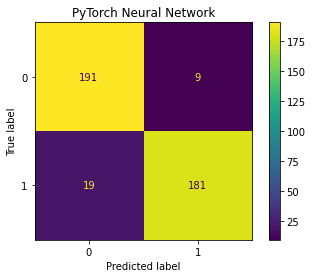

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title(
    "PyTorch Neural Network"
)

plt.show()

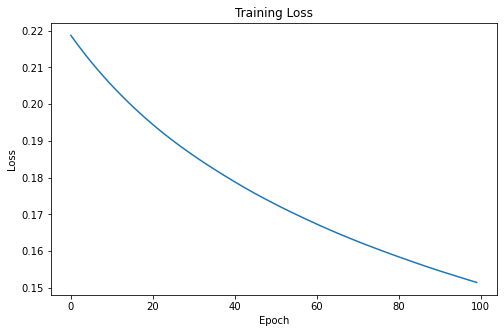

In [53]:
#plot training loss:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

# If loss doesn't decrease, something may be wrong with:

# learning rate
# model architecture
# data preprocessing
# labels
# optimizer
# loss function
# training configuration

In [54]:
# save the model:
torch.save(
    model.state_dict(),
    "diabetes_nn.pth"
)

In [ ]:
#Load the Model
#firts create the same architecture
loaded_model = DiabetesNN()
loaded_model.load_state_dict(
    torch.load(
        "diabetes_nn.pth"
    )
)
loaded_model.eval()
# now can be used for inference.